In [4]:
# %% ライブラリ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from scipy.stats import ks_2samp, chi2_contingency
from sklearn.metrics import accuracy_score
from sklearn.kernel_ridge import KernelRidge
import os


In [20]:
input_dir = os.path.join("in", "PWSCUP2025_Pre_Data_for_Attack")
files = sorted(f for f in os.listdir(input_dir) if f.startswith("A") and f.endswith(".csv"))
result = [os.path.join(input_dir, file) for file in files]
if not result:
    raise FileNotFoundError("No CSV files starting with 'A' were found in in/PWSCUP2025_Pre_Data_for_Attack.")


In [21]:
result

['in\\PWSCUP2025_Pre_Data_for_Attack\\A01.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A02.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A03.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A04.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A05.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A06.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A07.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A08.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A09.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A10.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A11.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A12.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A13.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A14.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A15.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A16.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A17.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A18.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A19.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A20.csv',
 'in\\PWSCUP2025_Pre_Data_for_Attack\\A2

In [22]:
MAX_SAMPLE_PER_DATASET = 5000

datasets = []
dataset_names = []

for fp in result:
    df = pd.read_csv(fp)
    if MAX_SAMPLE_PER_DATASET is not None and len(df) > MAX_SAMPLE_PER_DATASET:
        df = df.sample(n=MAX_SAMPLE_PER_DATASET, random_state=42)
    datasets.append(df.reset_index(drop=True))
    dataset_names.append(os.path.splitext(os.path.basename(fp))[0])

if not datasets:
    raise ValueError("No datasets were loaded. Confirm that the file list is correct.")



=== Data1: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          F            NaN   white  nonhispanic              NaN   
freq     50017            NaN   79742        86579              NaN   
mean       NaN      45.140370     NaN          NaN        60.594910   
std        NaN      25.901542     NaN          NaN        91.748689   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      24.000000     NaN          NaN        25.000000   
50%        NaN      44.000000     NaN          NaN        37.000000   
75%        NaN      64.000000     NaN          NaN        59.000000   
max        NaN     110.000000     NaN          NaN      1026.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      100

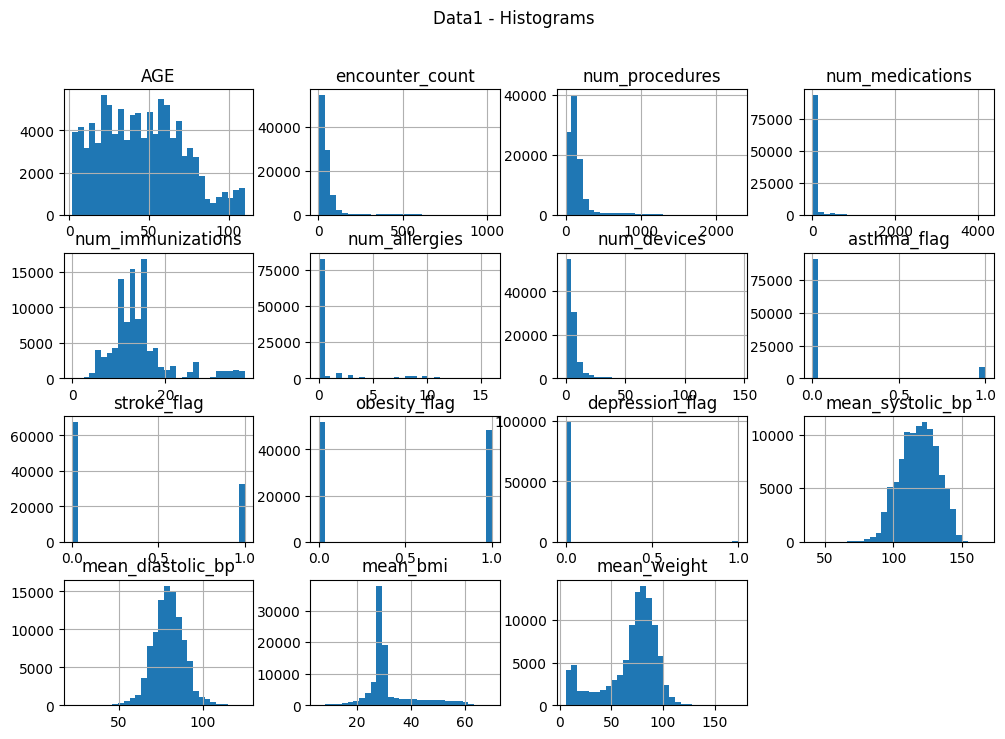


=== Data2: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     51145            NaN   95559        92791              NaN   
mean       NaN      42.473430     NaN          NaN        54.439260   
std        NaN      22.536391     NaN          NaN        78.811586   
min        NaN       2.000000     NaN          NaN         6.000000   
25%        NaN      24.000000     NaN          NaN        24.000000   
50%        NaN      45.000000     NaN          NaN        35.000000   
75%        NaN      60.000000     NaN          NaN        55.000000   
max        NaN     110.000000     NaN          NaN       943.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      100

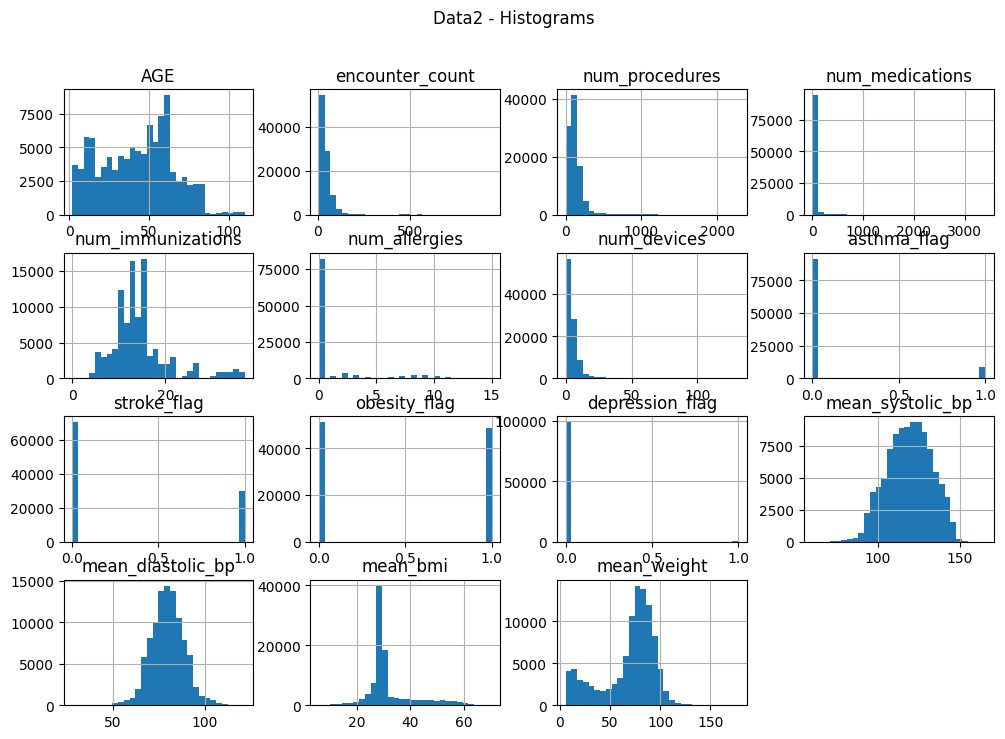


=== Data3: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     50818            NaN   67993        96117              NaN   
mean       NaN      49.194780     NaN          NaN        69.993520   
std        NaN      27.584178     NaN          NaN       105.667653   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      26.000000     NaN          NaN        26.000000   
50%        NaN      51.000000     NaN          NaN        40.000000   
75%        NaN      68.000000     NaN          NaN        66.000000   
max        NaN     110.000000     NaN          NaN       979.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      100

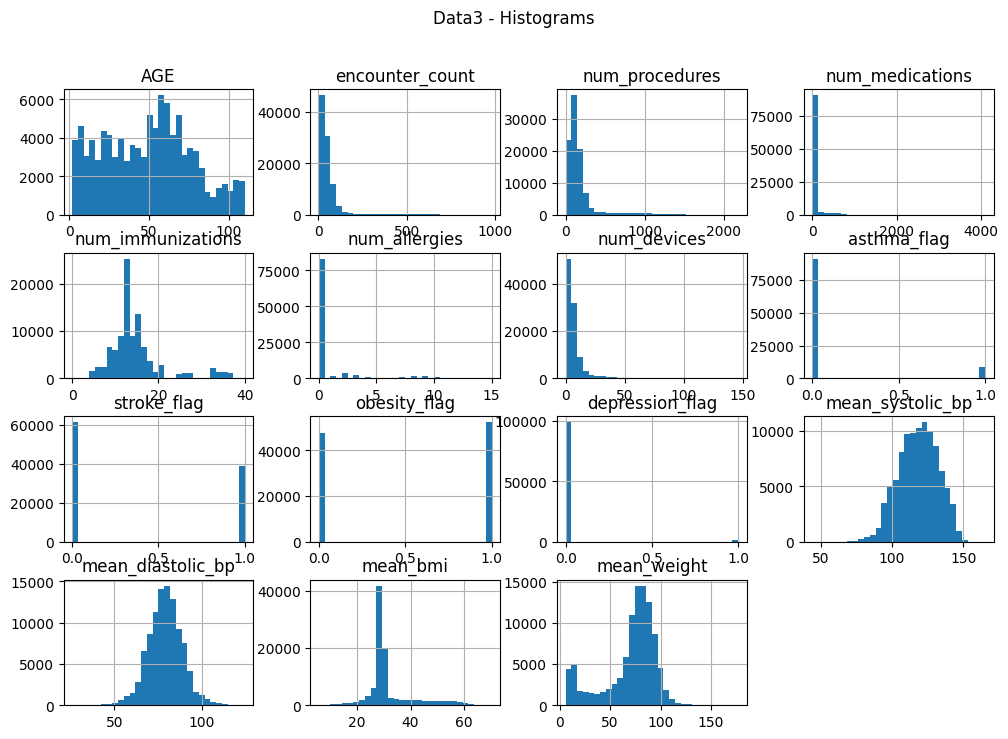


=== Data4: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     50973            NaN   92099        86096              NaN   
mean       NaN      54.093680     NaN          NaN        68.566890   
std        NaN      21.794228     NaN          NaN       102.390818   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      45.000000     NaN          NaN        28.000000   
50%        NaN      53.000000     NaN          NaN        41.000000   
75%        NaN      72.000000     NaN          NaN        63.000000   
max        NaN     110.000000     NaN          NaN      1025.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      100

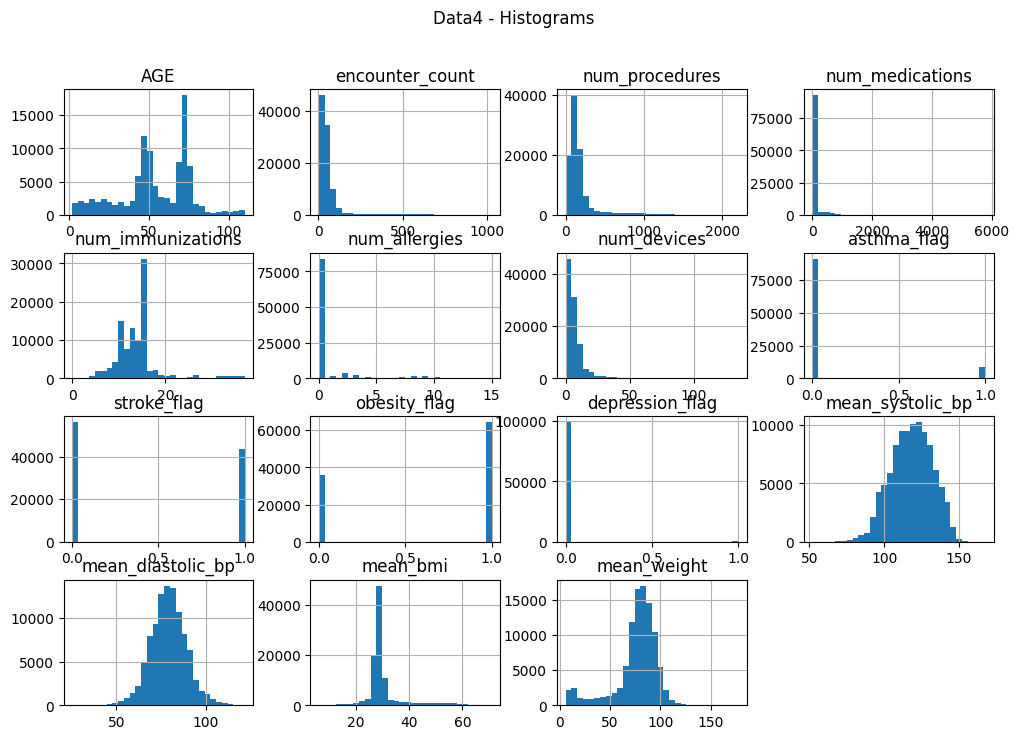


=== Data5: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          F            NaN   white  nonhispanic              NaN   
freq     50306            NaN   69250        85576              NaN   
mean       NaN      43.284490     NaN          NaN        60.525170   
std        NaN      25.731424     NaN          NaN        91.087898   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      22.000000     NaN          NaN        24.000000   
50%        NaN      42.000000     NaN          NaN        36.000000   
75%        NaN      62.000000     NaN          NaN        60.000000   
max        NaN     110.000000     NaN          NaN      1003.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      100

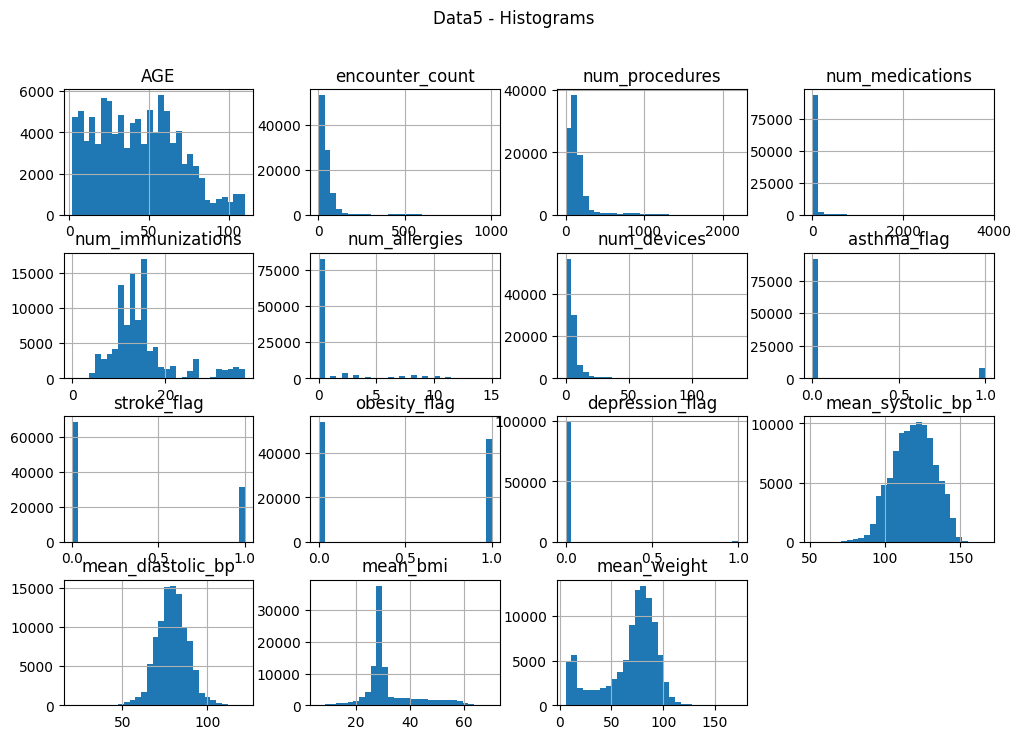


=== Data6: 基本統計量 ===
        GENDER            AGE    RACE ETHNICITY  encounter_count  \
count   100000  100000.000000  100000    100000    100000.000000   
unique       2            NaN       6         2              NaN   
top          M            NaN   white  hispanic              NaN   
freq     50526            NaN   96264     50476              NaN   
mean       NaN      33.862800     NaN       NaN        46.455580   
std        NaN      23.612172     NaN       NaN        69.224039   
min        NaN       2.000000     NaN       NaN         6.000000   
25%        NaN      15.000000     NaN       NaN        21.000000   
50%        NaN      27.000000     NaN       NaN        30.000000   
75%        NaN      52.000000     NaN       NaN        48.000000   
max        NaN     110.000000     NaN       NaN      1107.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      100000.000000  100000.000000   
unique 

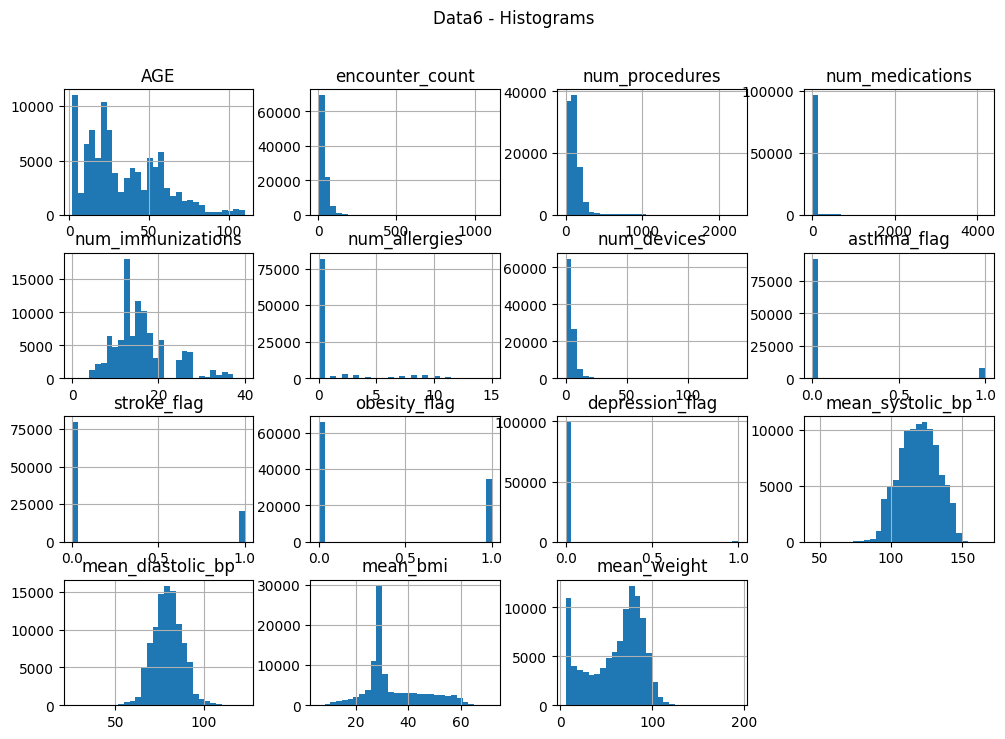


=== Data7: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     52245            NaN   79717        98604              NaN   
mean       NaN      49.710040     NaN          NaN        68.582220   
std        NaN      25.962739     NaN          NaN       101.150785   
min        NaN       2.000000     NaN          NaN         6.000000   
25%        NaN      29.000000     NaN          NaN        27.000000   
50%        NaN      52.000000     NaN          NaN        40.000000   
75%        NaN      68.000000     NaN          NaN        66.000000   
max        NaN     110.000000     NaN          NaN       943.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      100

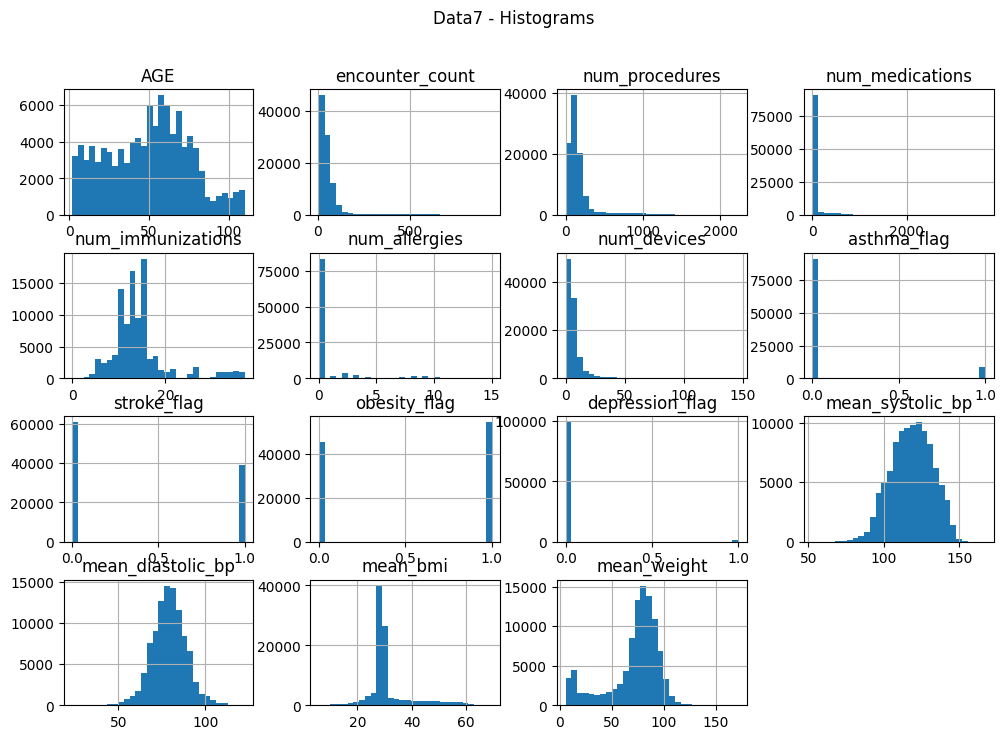


=== Data8: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000     100000.00000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     50225            NaN   77098        86382              NaN   
mean       NaN      45.902050     NaN          NaN         61.24665   
std        NaN      25.669551     NaN          NaN         92.14456   
min        NaN       2.000000     NaN          NaN          4.00000   
25%        NaN      25.000000     NaN          NaN         25.00000   
50%        NaN      46.000000     NaN          NaN         37.00000   
75%        NaN      64.000000     NaN          NaN         60.00000   
max        NaN     110.000000     NaN          NaN       1133.00000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000     100000.00000      100

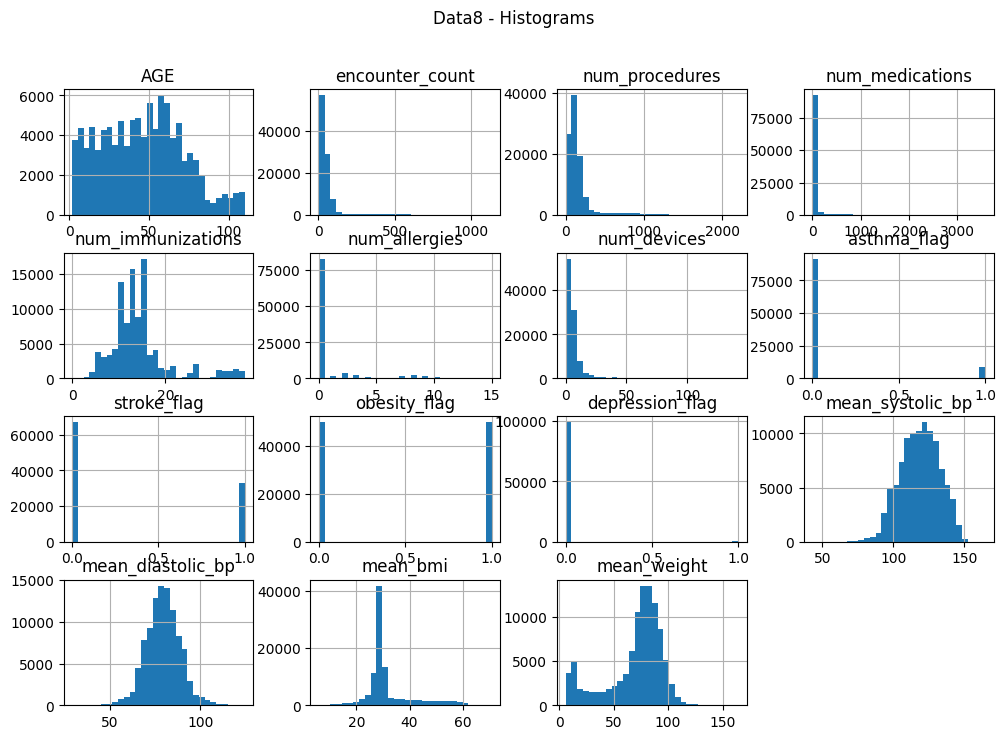


=== Data9: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     51445            NaN   95425        83690              NaN   
mean       NaN      51.223460     NaN          NaN        65.166850   
std        NaN      25.374756     NaN          NaN       100.484811   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      31.000000     NaN          NaN        27.000000   
50%        NaN      55.000000     NaN          NaN        38.000000   
75%        NaN      69.000000     NaN          NaN        58.000000   
max        NaN     110.000000     NaN          NaN       962.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      100

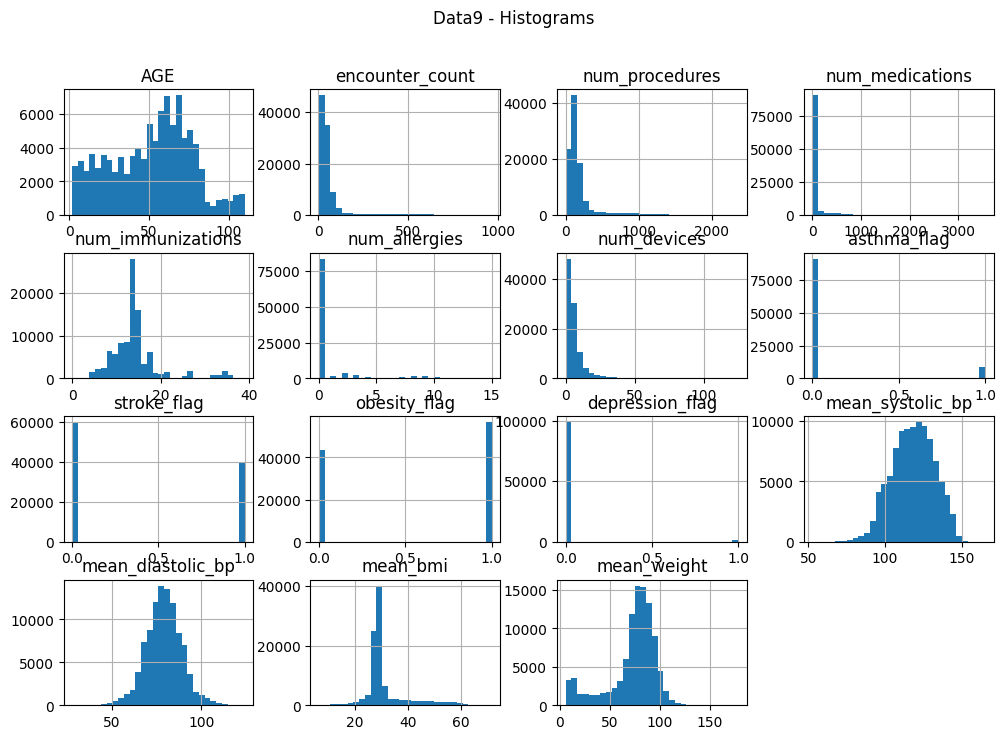


=== Data10: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     50280            NaN   75975        82114              NaN   
mean       NaN      44.136090     NaN          NaN        61.064490   
std        NaN      25.588457     NaN          NaN        89.538118   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      21.000000     NaN          NaN        25.000000   
50%        NaN      44.000000     NaN          NaN        37.000000   
75%        NaN      63.000000     NaN          NaN        61.000000   
max        NaN     110.000000     NaN          NaN       944.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000       1

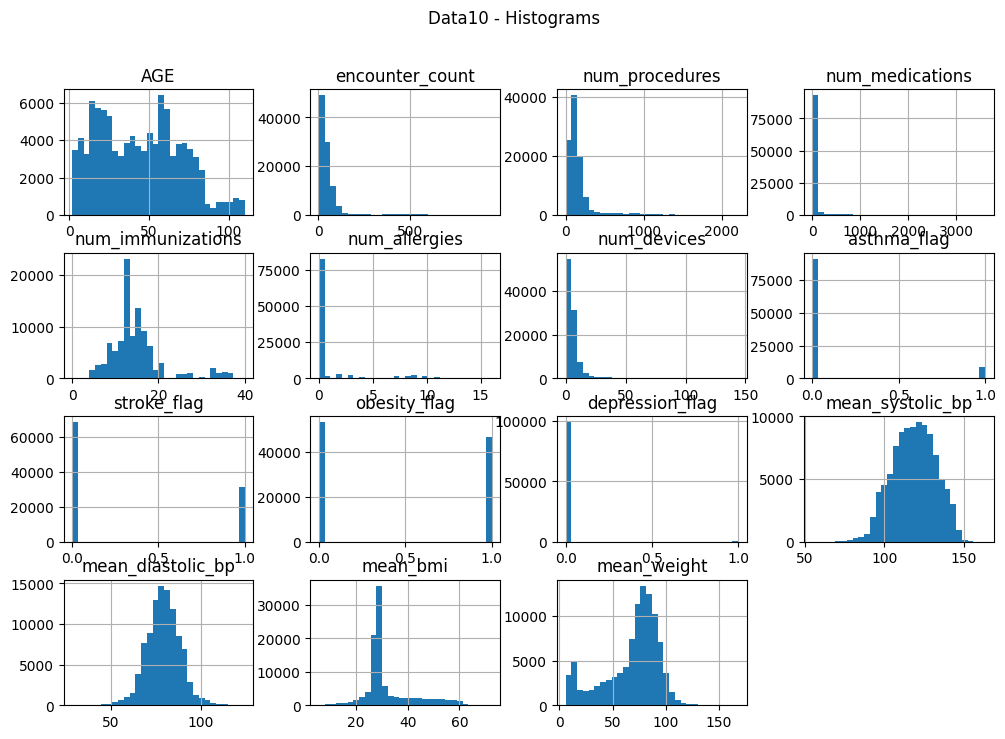


=== Data11: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     51618            NaN   95846        60346              NaN   
mean       NaN      45.176740     NaN          NaN        63.167100   
std        NaN      26.590693     NaN          NaN        92.220732   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      21.000000     NaN          NaN        25.000000   
50%        NaN      47.000000     NaN          NaN        38.000000   
75%        NaN      65.000000     NaN          NaN        64.000000   
max        NaN     110.000000     NaN          NaN       943.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      10

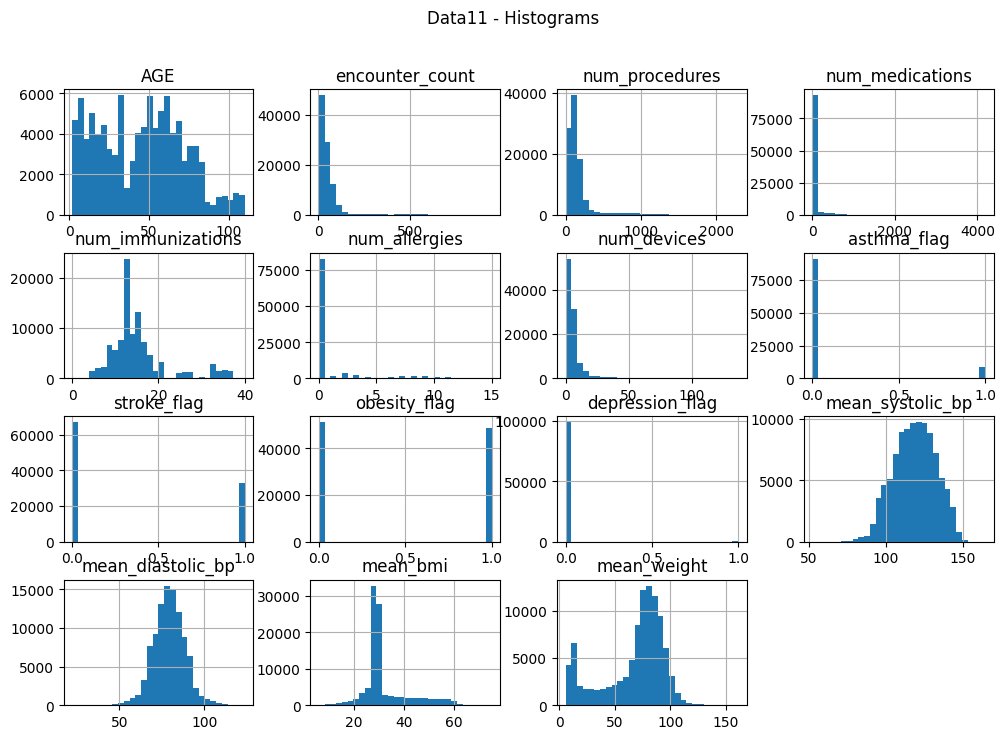


=== Data12: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     53403            NaN   82260        93230              NaN   
mean       NaN      41.734770     NaN          NaN        54.783350   
std        NaN      24.159251     NaN          NaN        83.699269   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      22.000000     NaN          NaN        24.000000   
50%        NaN      40.000000     NaN          NaN        34.000000   
75%        NaN      58.000000     NaN          NaN        54.000000   
max        NaN     110.000000     NaN          NaN       982.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      10

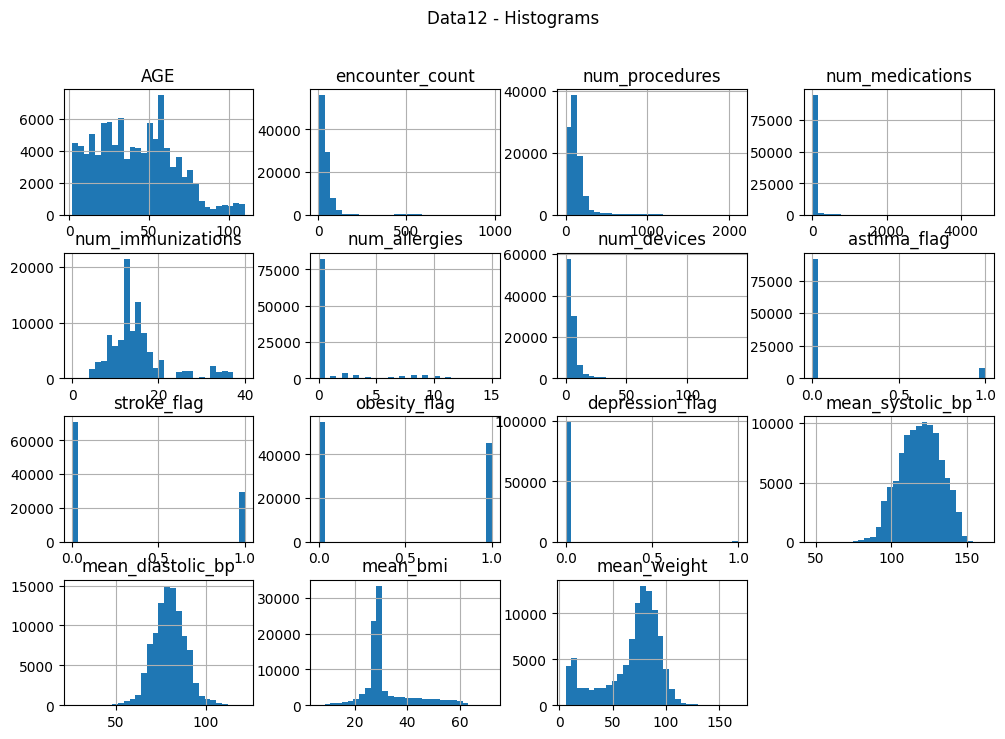


=== Data13: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          F            NaN   white  nonhispanic              NaN   
freq     50272            NaN   73906        94379              NaN   
mean       NaN      43.265940     NaN          NaN        58.348000   
std        NaN      25.518986     NaN          NaN        89.293451   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      22.000000     NaN          NaN        24.000000   
50%        NaN      42.000000     NaN          NaN        36.000000   
75%        NaN      62.000000     NaN          NaN        56.000000   
max        NaN     110.000000     NaN          NaN       991.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      10

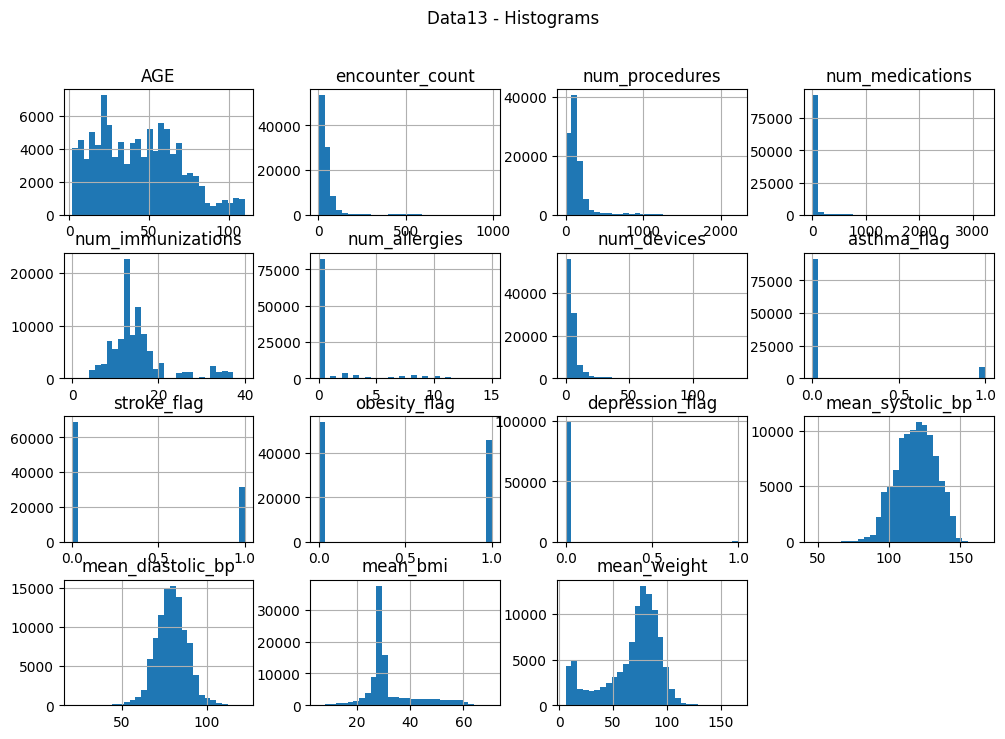


=== Data14: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     53054            NaN   69053        86332              NaN   
mean       NaN      52.539340     NaN          NaN        71.872430   
std        NaN      26.009433     NaN          NaN       106.991826   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      32.000000     NaN          NaN        28.000000   
50%        NaN      56.000000     NaN          NaN        41.000000   
75%        NaN      72.000000     NaN          NaN        66.000000   
max        NaN     110.000000     NaN          NaN      1074.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count     100000.00000     100000.00000      10

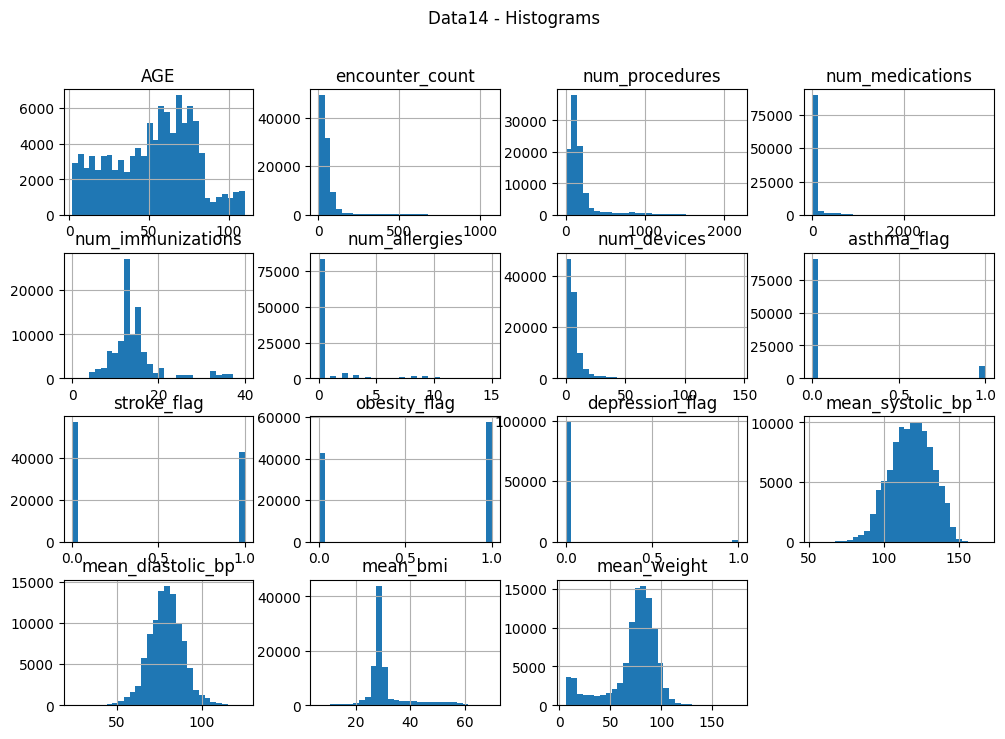


=== Data15: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     50408            NaN   75653        97750              NaN   
mean       NaN      51.271780     NaN          NaN        68.040610   
std        NaN      26.650825     NaN          NaN       104.898485   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      30.000000     NaN          NaN        27.000000   
50%        NaN      56.000000     NaN          NaN        38.000000   
75%        NaN      67.000000     NaN          NaN        60.000000   
max        NaN     110.000000     NaN          NaN      1065.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      10

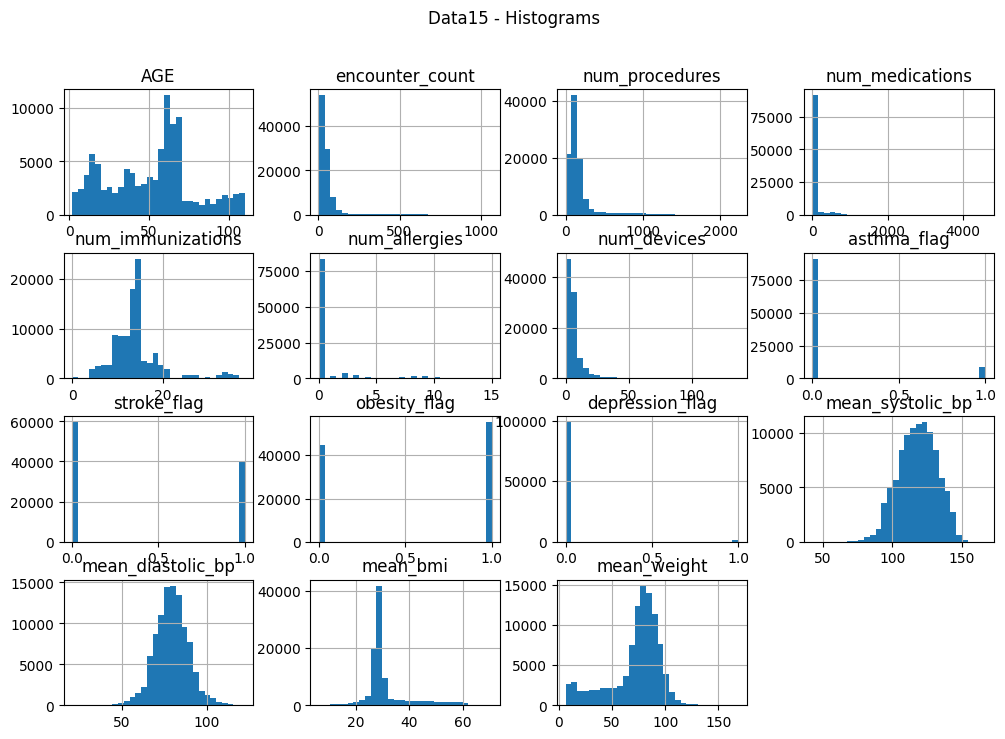


=== Data16: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     50342            NaN   85544        64948              NaN   
mean       NaN      42.330550     NaN          NaN        58.848890   
std        NaN      25.015912     NaN          NaN        85.118579   
min        NaN       2.000000     NaN          NaN         6.000000   
25%        NaN      21.000000     NaN          NaN        24.000000   
50%        NaN      41.000000     NaN          NaN        37.000000   
75%        NaN      61.000000     NaN          NaN        60.000000   
max        NaN     110.000000     NaN          NaN       937.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000       1

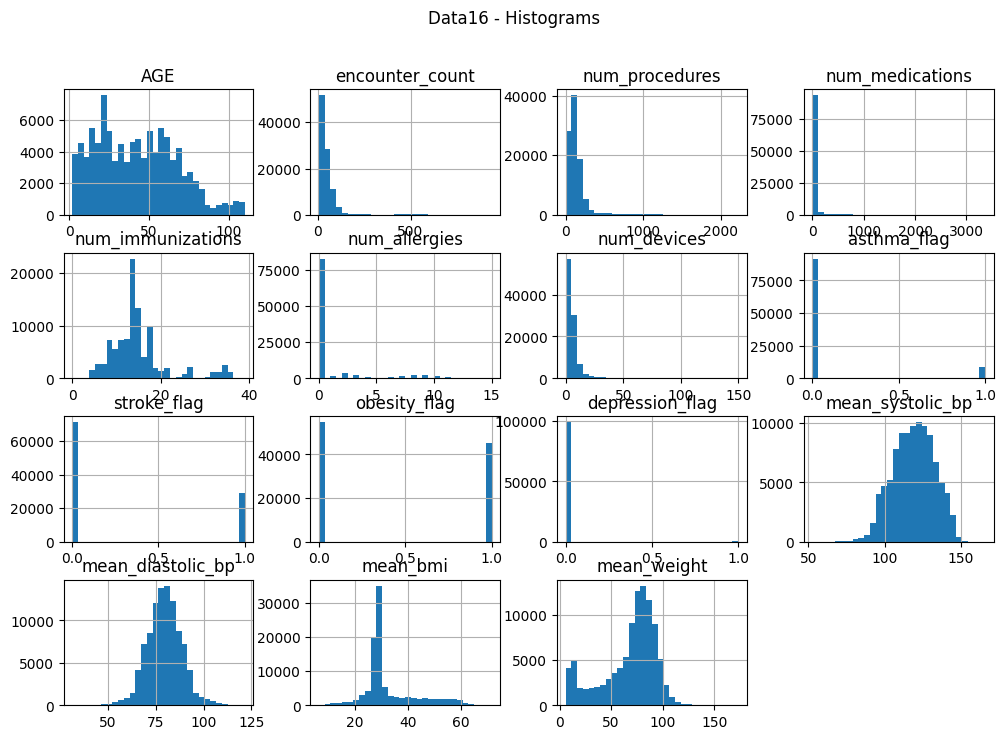


=== Data17: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     52102            NaN   85621        93538              NaN   
mean       NaN      51.804160     NaN          NaN        68.356100   
std        NaN      26.208669     NaN          NaN       103.861167   
min        NaN       2.000000     NaN          NaN         6.000000   
25%        NaN      32.000000     NaN          NaN        27.000000   
50%        NaN      55.000000     NaN          NaN        39.000000   
75%        NaN      69.000000     NaN          NaN        62.000000   
max        NaN     110.000000     NaN          NaN       989.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      10

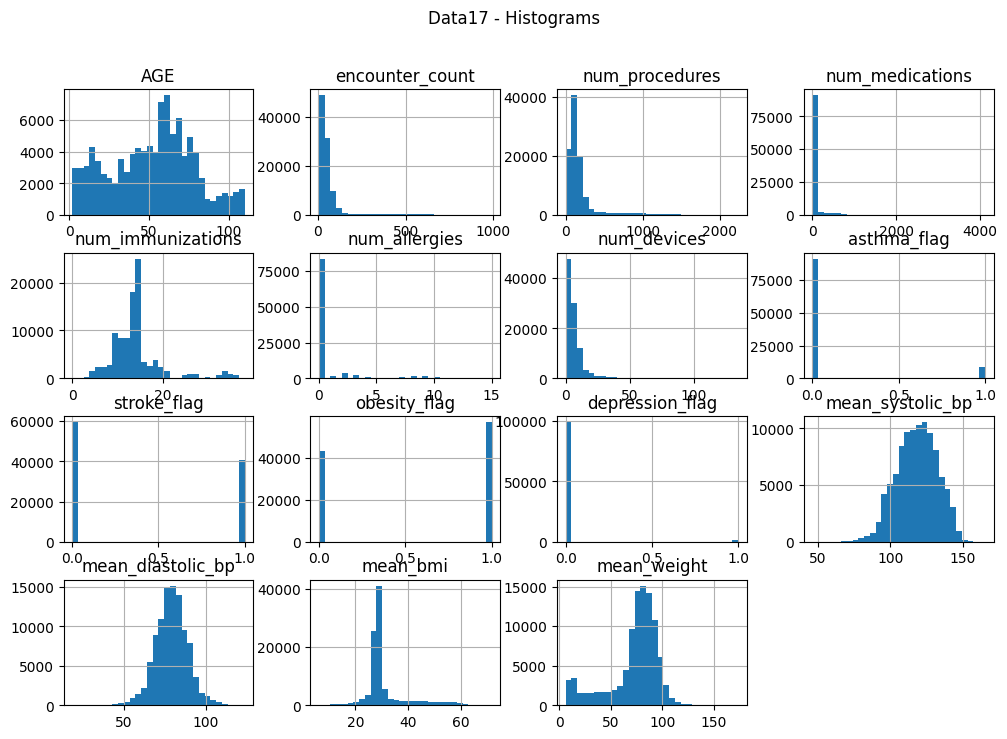


=== Data18: 基本統計量 ===
        GENDER           AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.00000  100000       100000    100000.000000   
unique       2           NaN       6            2              NaN   
top          M           NaN   white  nonhispanic              NaN   
freq     50949           NaN   71100        89237              NaN   
mean       NaN      42.87020     NaN          NaN        55.779970   
std        NaN      23.55117     NaN          NaN        84.118084   
min        NaN       2.00000     NaN          NaN         5.000000   
25%        NaN      23.00000     NaN          NaN        24.000000   
50%        NaN      45.00000     NaN          NaN        35.000000   
75%        NaN      60.00000     NaN          NaN        55.000000   
max        NaN     110.00000     NaN          NaN       918.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      100000.000000 

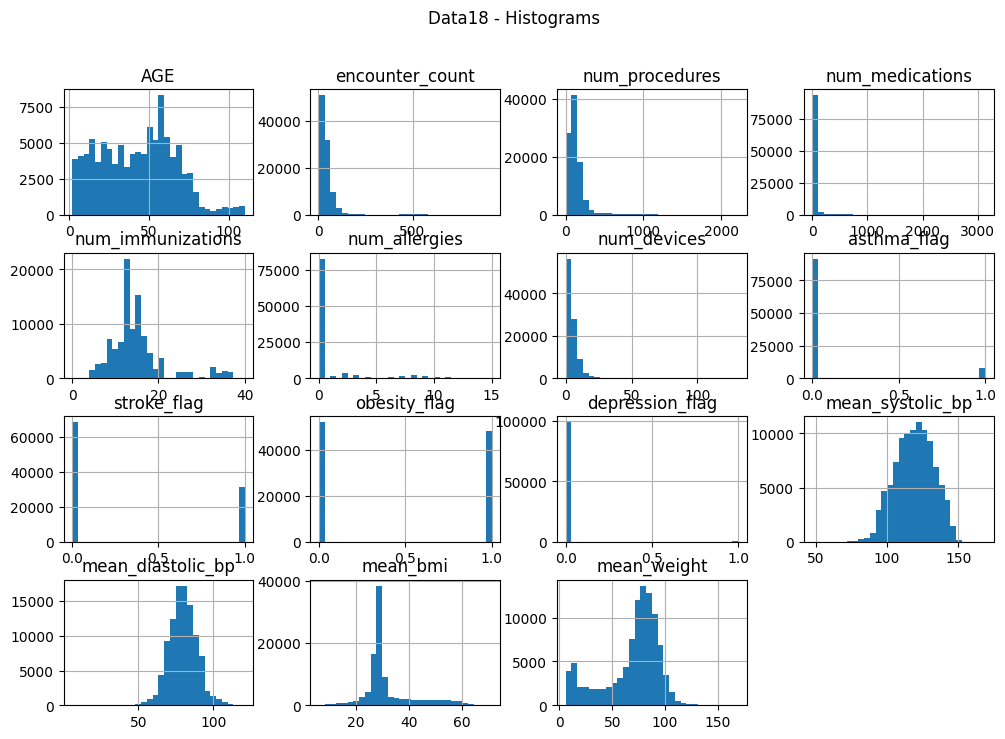


=== Data19: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     50334            NaN   75139        95142              NaN   
mean       NaN      41.943410     NaN          NaN        56.467480   
std        NaN      25.365141     NaN          NaN        86.256829   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      22.000000     NaN          NaN        24.000000   
50%        NaN      40.000000     NaN          NaN        35.000000   
75%        NaN      59.000000     NaN          NaN        55.000000   
max        NaN     110.000000     NaN          NaN       907.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      10

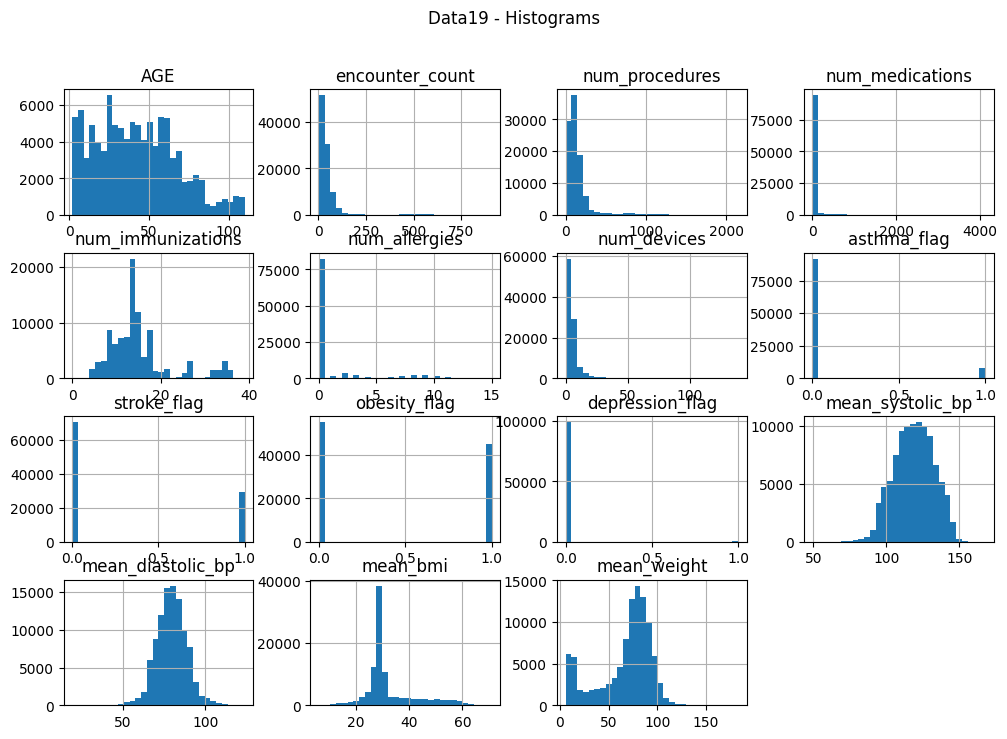


=== Data20: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          F            NaN   white  nonhispanic              NaN   
freq     50131            NaN   88395        96889              NaN   
mean       NaN      49.518150     NaN          NaN        66.018100   
std        NaN      26.449689     NaN          NaN       101.021905   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      27.000000     NaN          NaN        26.000000   
50%        NaN      51.000000     NaN          NaN        38.000000   
75%        NaN      69.000000     NaN          NaN        61.000000   
max        NaN     110.000000     NaN          NaN       995.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      10

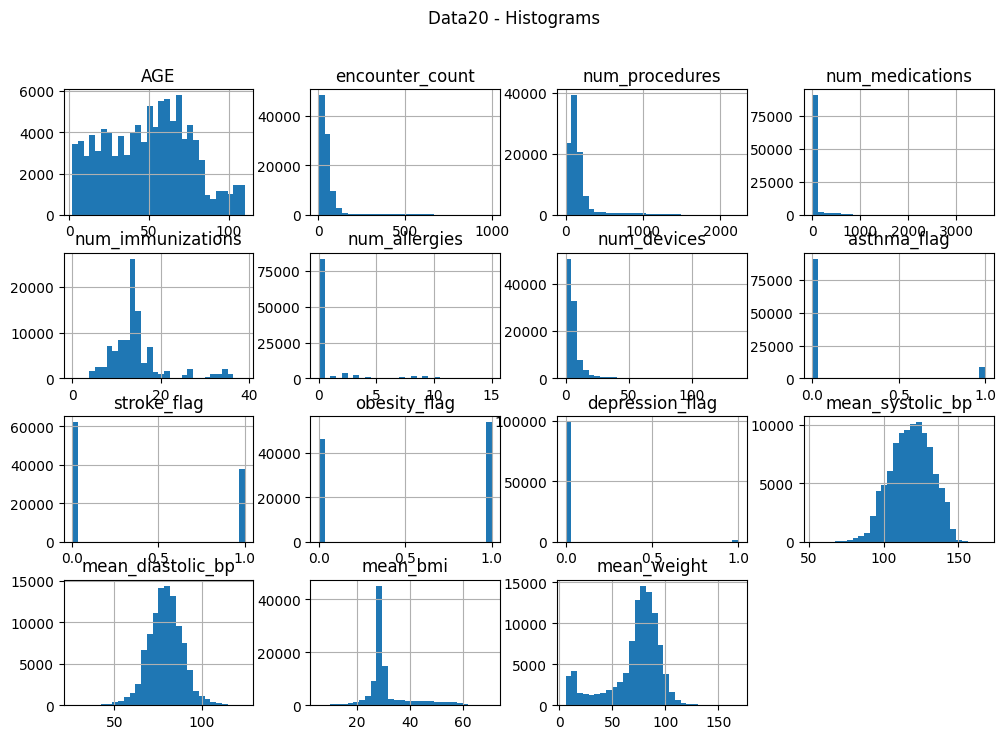


=== Data21: 基本統計量 ===
        GENDER            AGE    RACE    ETHNICITY  encounter_count  \
count   100000  100000.000000  100000       100000    100000.000000   
unique       2            NaN       6            2              NaN   
top          M            NaN   white  nonhispanic              NaN   
freq     50818            NaN   90154        84818              NaN   
mean       NaN      43.298010     NaN          NaN        58.852170   
std        NaN      25.238451     NaN          NaN        87.153318   
min        NaN       2.000000     NaN          NaN         5.000000   
25%        NaN      21.000000     NaN          NaN        24.000000   
50%        NaN      44.000000     NaN          NaN        36.000000   
75%        NaN      62.000000     NaN          NaN        59.000000   
max        NaN     110.000000     NaN          NaN       987.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count    100000.000000    100000.000000      10

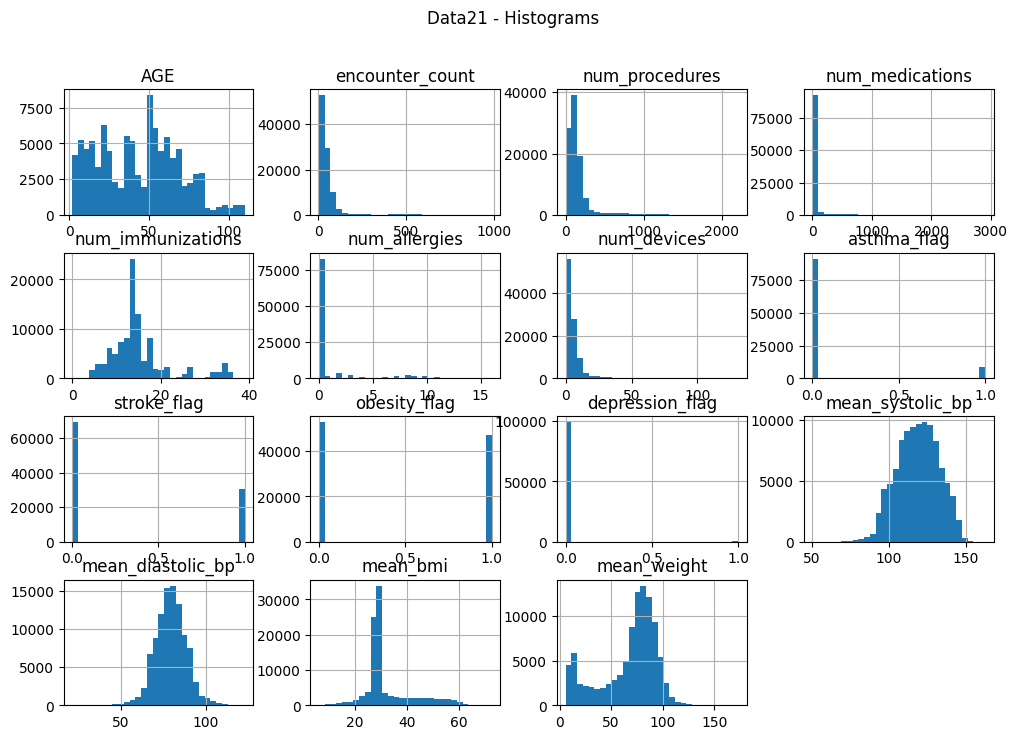

In [23]:
# %% 1. 基本統計量の比較
for name, df in zip(dataset_names, datasets):
    print(f"\n=== {name}: 基本統計量 ===")
    print(df.describe(include="all"))

    # 数値分布のヒストグラム
    df.hist(figsize=(12, 8), bins=30)
    plt.suptitle(f"{name} - Histograms")
    plt.show()

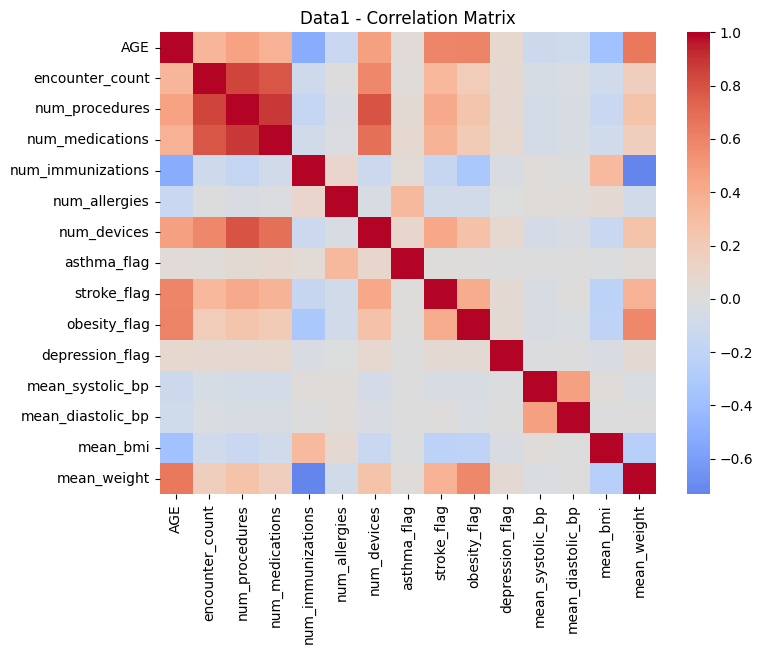

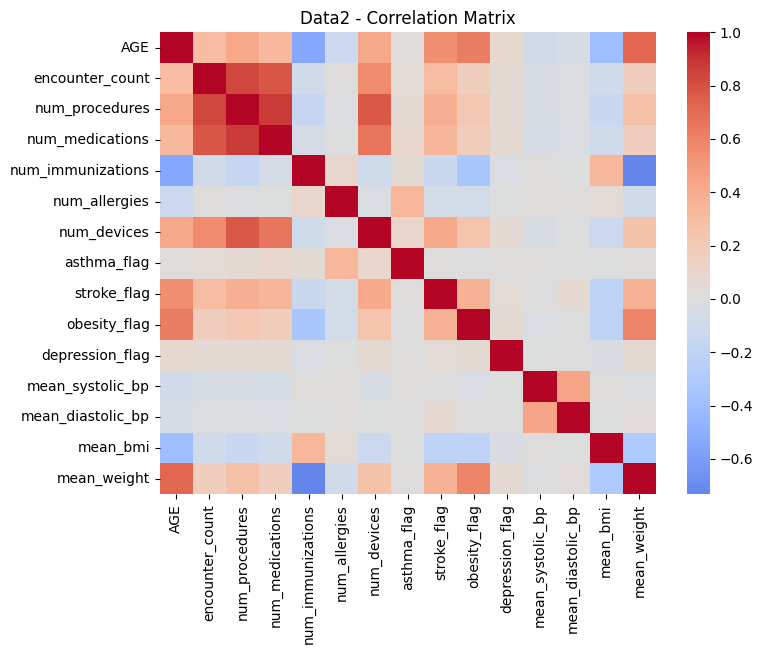

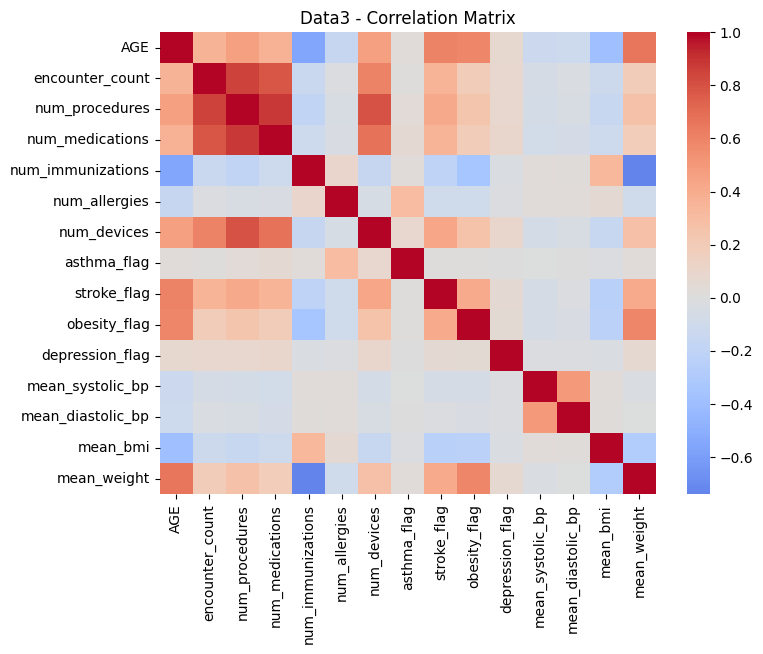

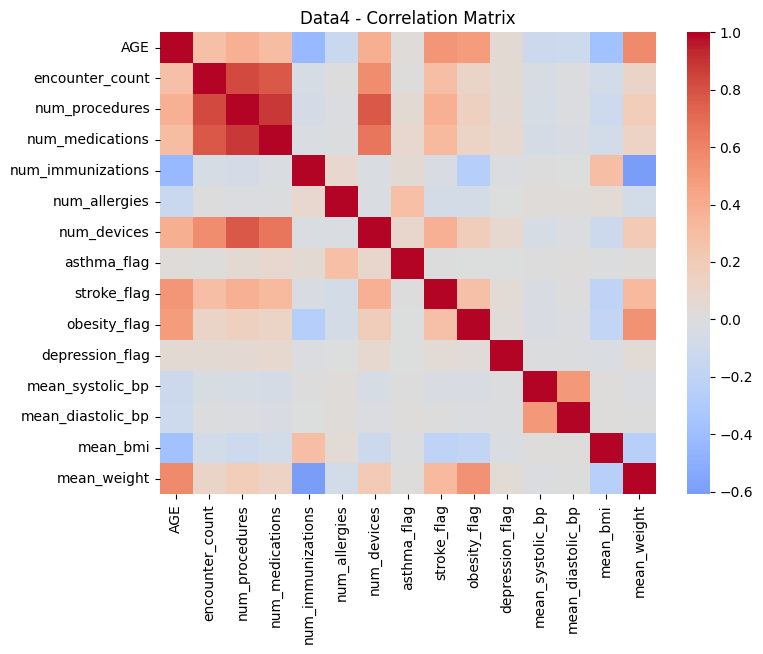

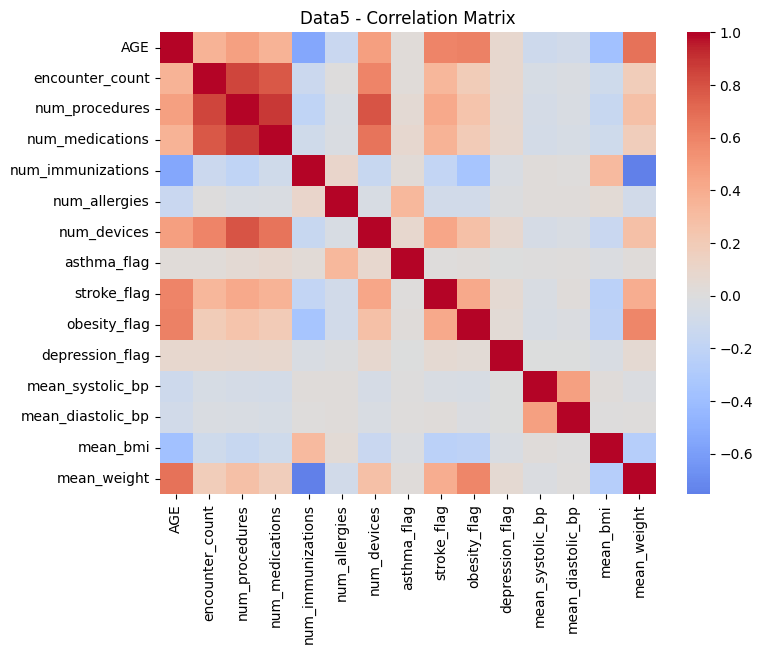

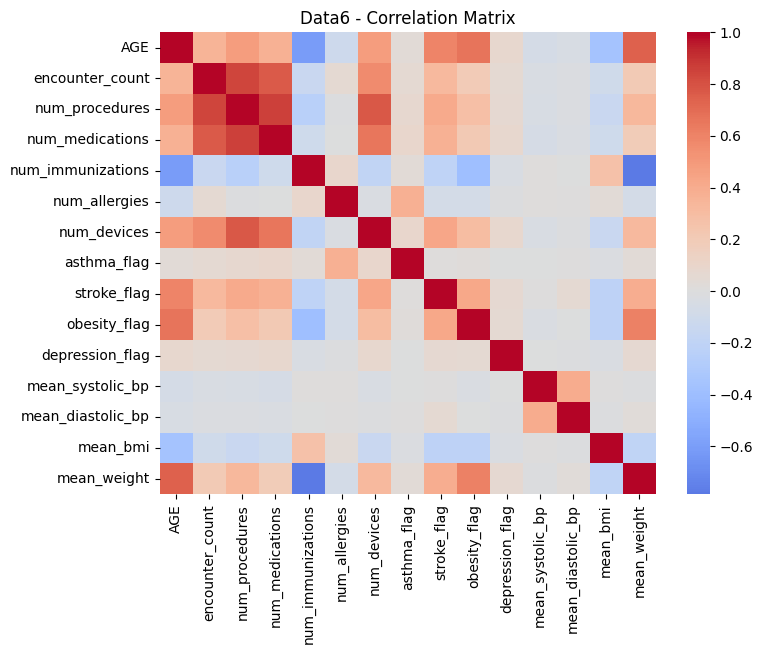

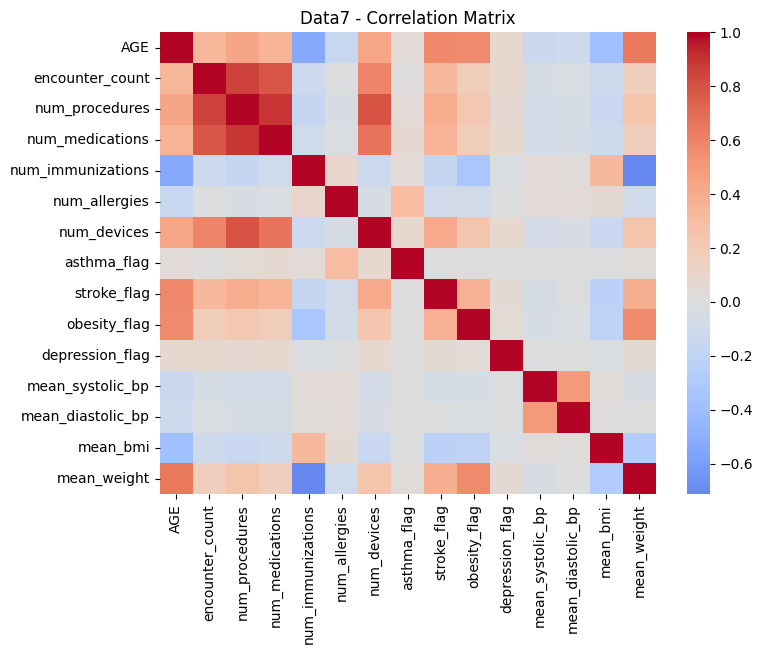

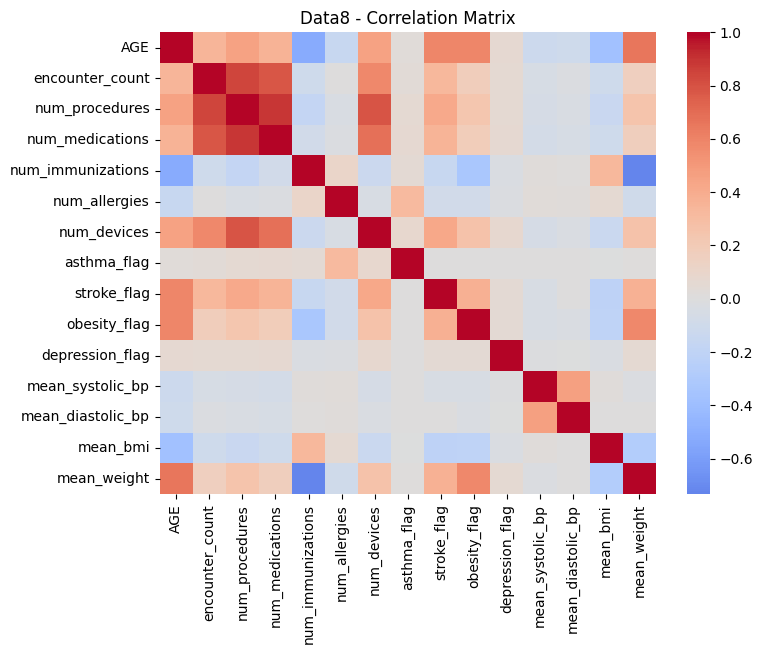

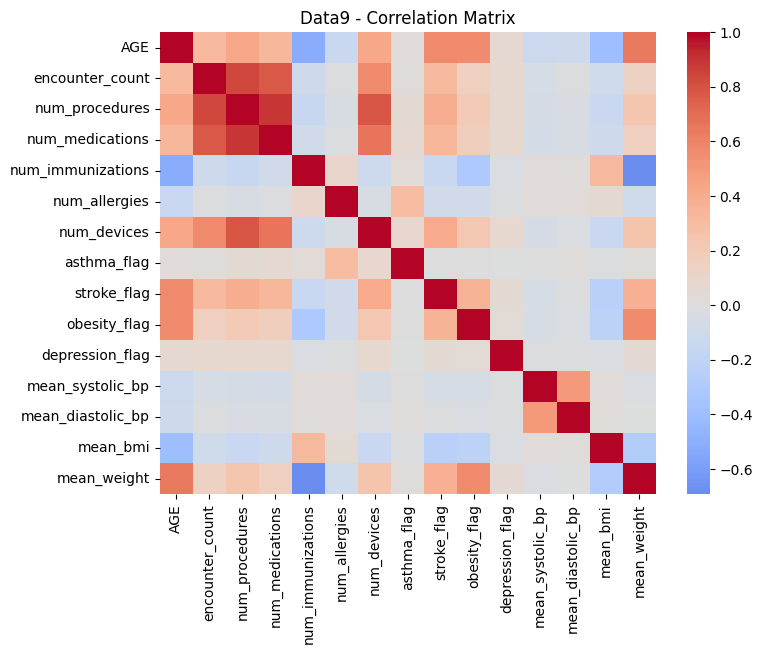

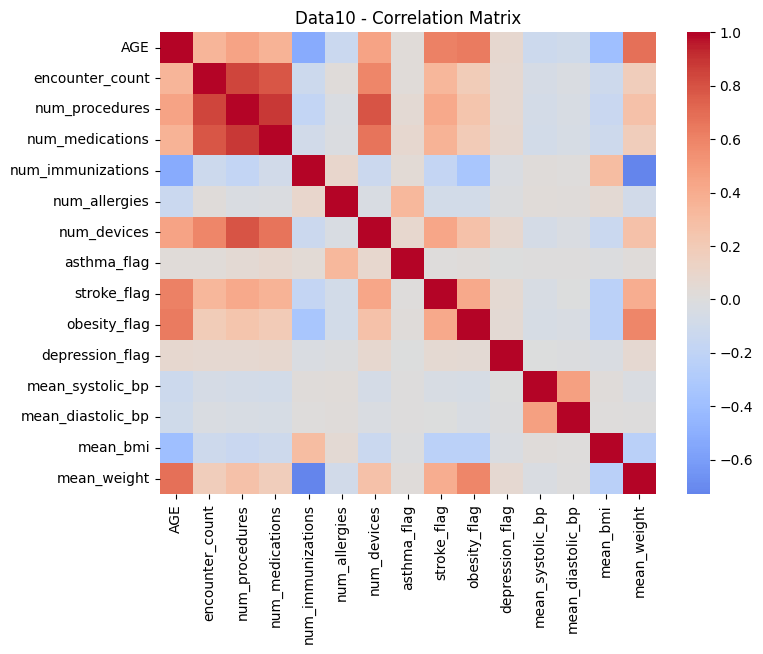

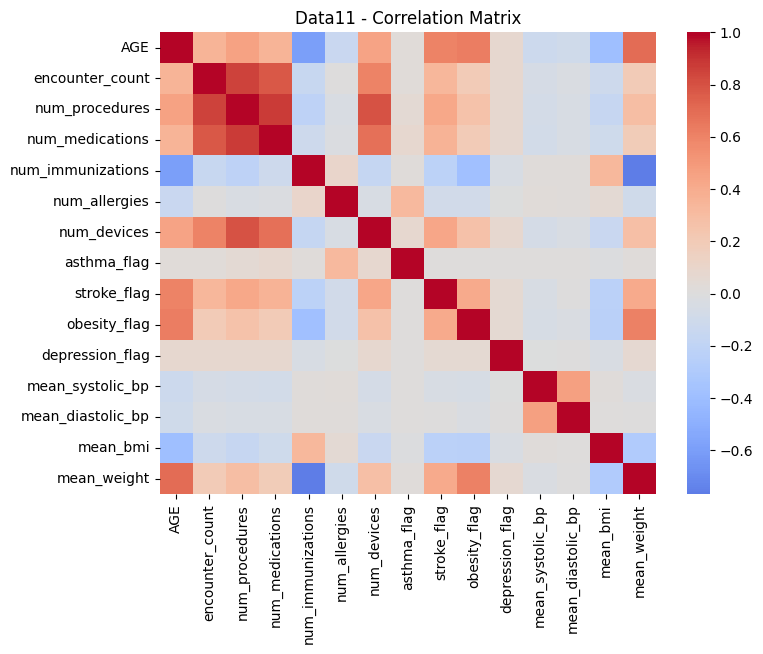

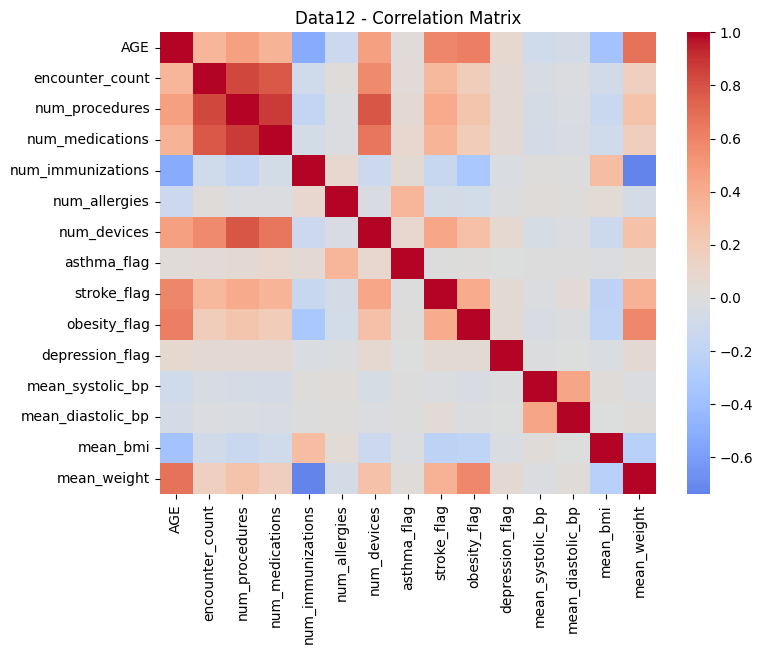

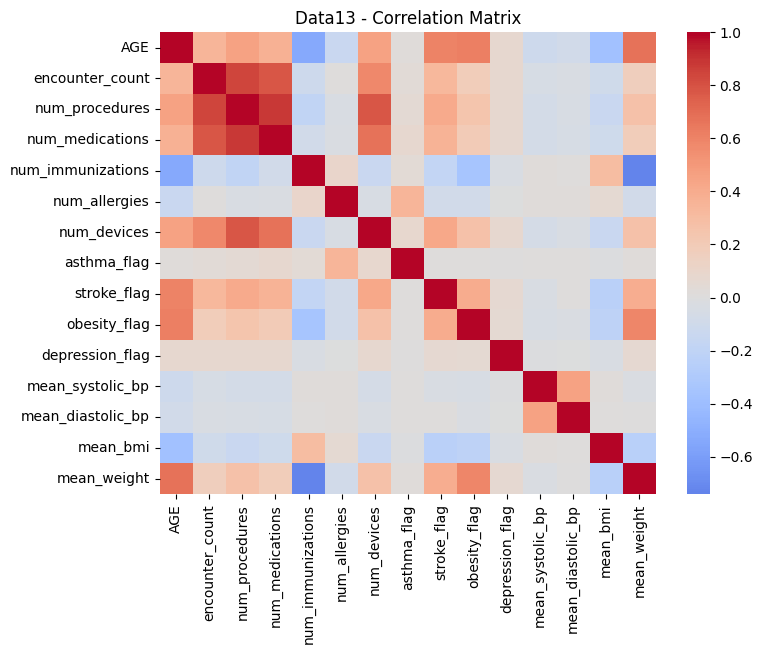

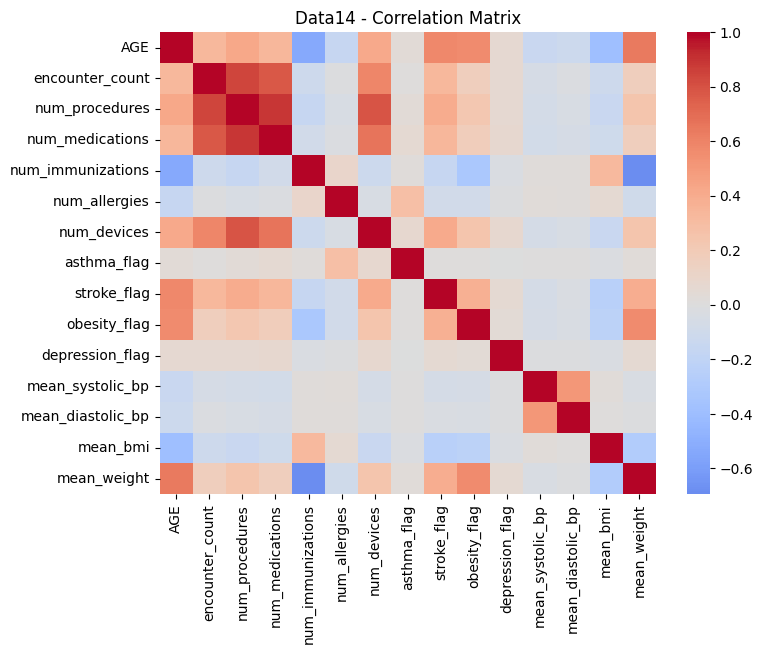

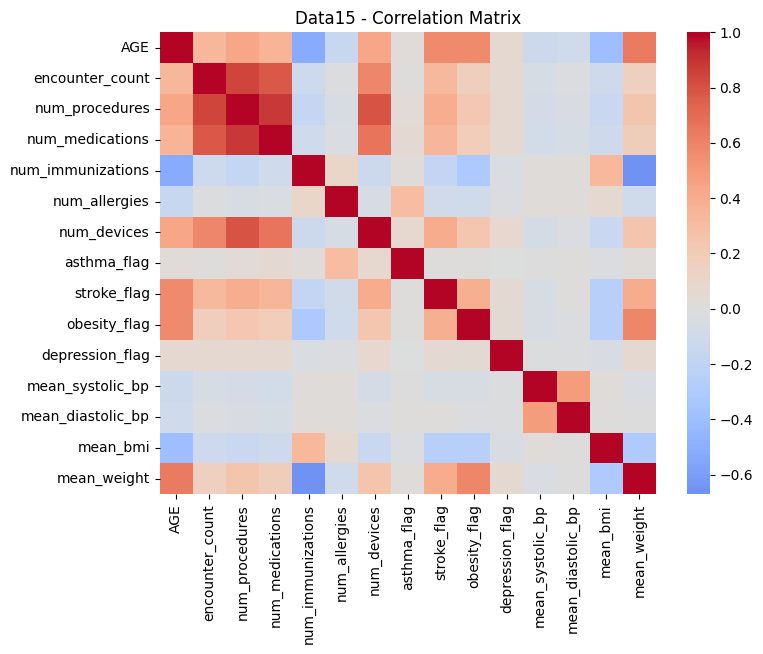

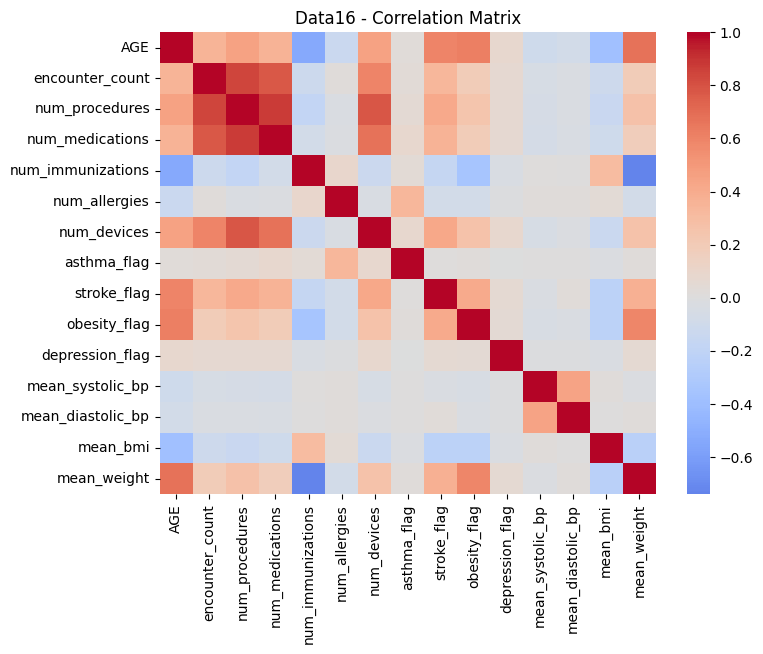

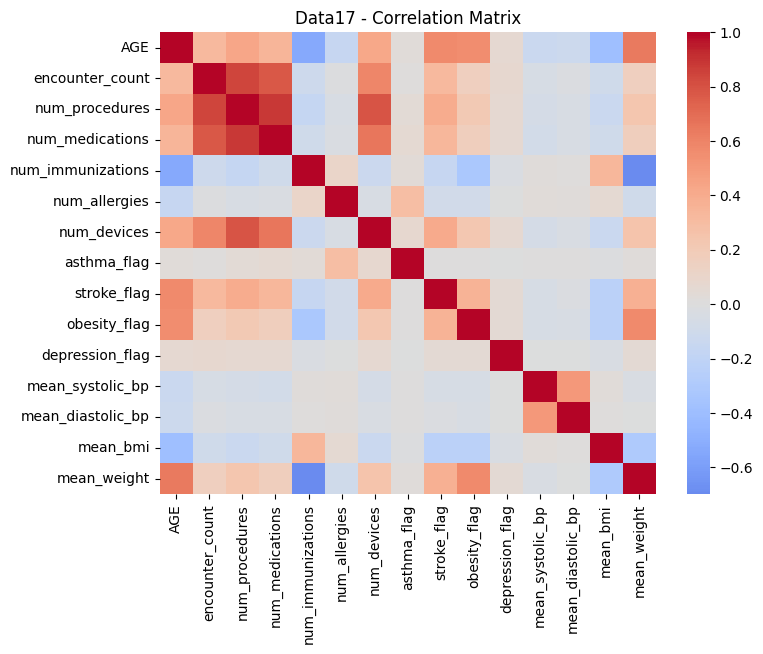

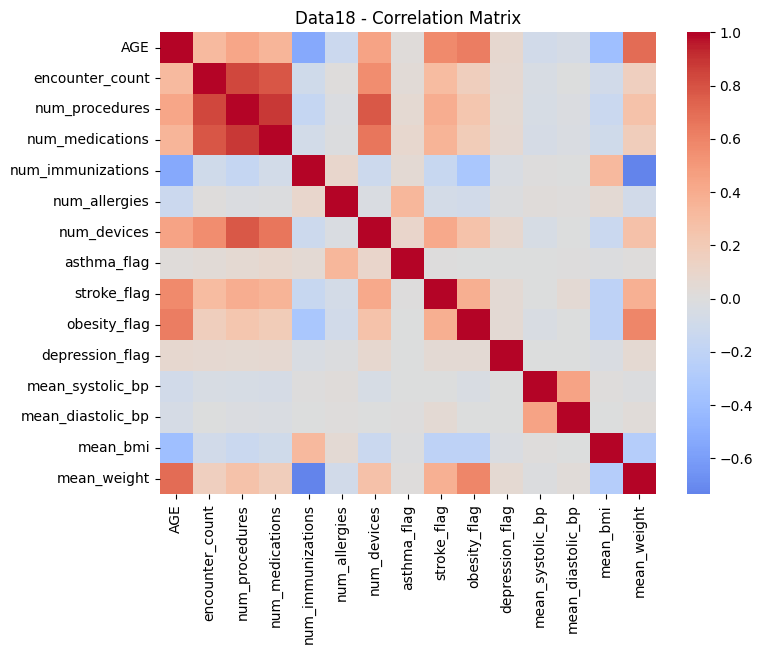

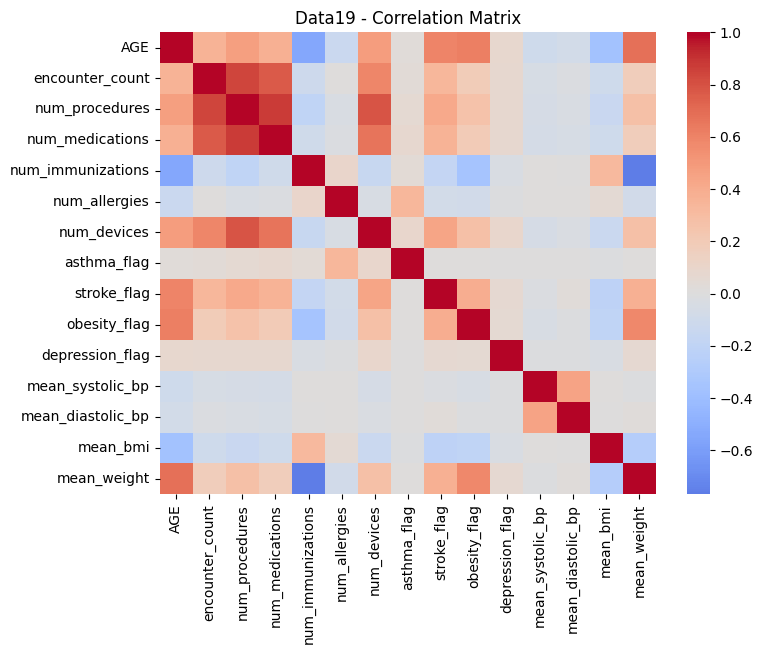

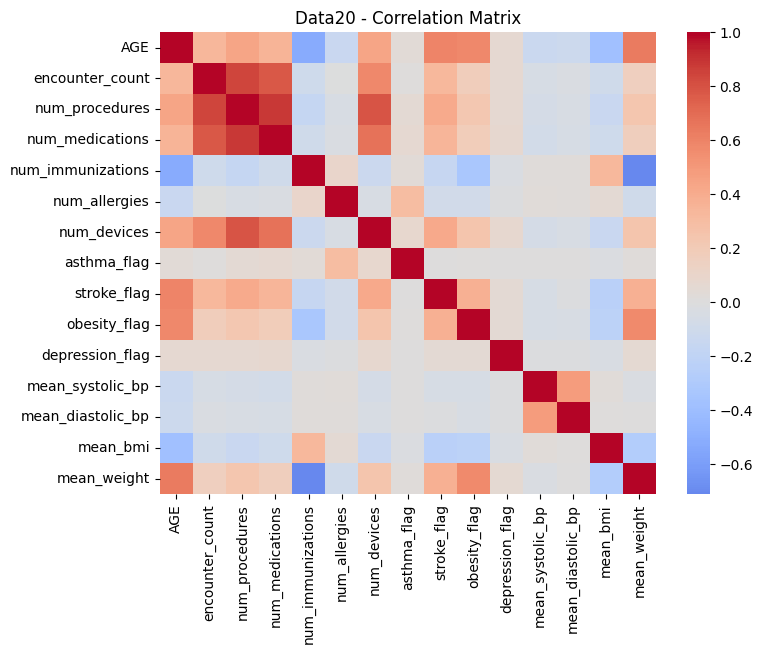

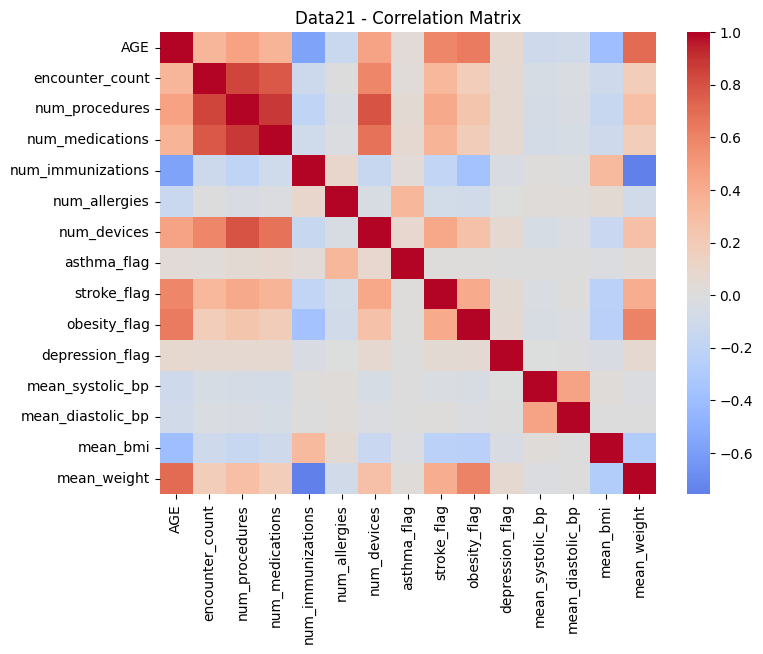

In [24]:
# %% 2. 相関構造の比較
for name, df in zip(dataset_names, datasets):
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
    plt.title(f"{name} - Correlation Matrix")
    plt.show()

In [25]:
# %% 3. 次元削減による可視化 (PCA, t-SNE)
combined = []
for i, df in enumerate(datasets):
    temp = df.copy()
    temp["source"] = dataset_names[i]
    combined.append(temp)
combined_df = pd.concat(combined, ignore_index=True)

feature_df = combined_df.drop(columns=["source"])
encoded_df = pd.get_dummies(feature_df, drop_first=False)
if encoded_df.empty:
    raise ValueError("特徴量が存在しません。入力データを確認してください。")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(encoded_df)
y = combined_df["source"]

rng = np.random.default_rng(42)
viz_sample_size = min(3000, X_scaled.shape[0])
if viz_sample_size < X_scaled.shape[0]:
    sample_idx = rng.choice(X_scaled.shape[0], viz_sample_size, replace=False)
else:
    sample_idx = np.arange(X_scaled.shape[0])

X_viz = X_scaled[sample_idx]
y_viz = y.iloc[sample_idx].reset_index(drop=True)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_viz)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_viz, alpha=0.6)
plt.title("PCA Visualization")
plt.show()

# t-SNE
perplexity = min(30, max(5, viz_sample_size - 1))
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
X_tsne = tsne.fit_transform(X_viz)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_viz, alpha=0.6)
plt.title("t-SNE Visualization")
plt.show()


ValueError: could not convert string to float: 'F'

In [ ]:
# %% 4. 判別モデルによる識別精度
clf = RandomForestClassifier(n_estimators=200, random_state=42)
scores = cross_val_score(clf, X_scaled, y, cv=5, scoring="accuracy")
print("\n=== 判別モデル精度 ===")
print(f"平均精度: {scores.mean():.3f} (± {scores.std():.3f})")
print("※ 精度が低ければ区別できない → データの特徴は類似")


In [ ]:
# %% 5. 統計的検定
print("
=== 分布の統計的検定 ===")
numeric_cols = combined_df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) == 0:
    print("数値列が見つかりませんでした。")
else:
    for col in numeric_cols:
        data_groups = [df[col].dropna() for df in datasets]
        for i in range(len(data_groups)):
            for j in range(i+1, len(data_groups)):
                if data_groups[i].empty or data_groups[j].empty:
                    continue
                stat, pval = ks_2samp(data_groups[i], data_groups[j])
                print(f"{col}: {dataset_names[i]} vs {dataset_names[j]} → p={pval:.4f}")

categorical_cols = combined_df.select_dtypes(include=["object", "category"]).columns
for col in categorical_cols:
    contingency = pd.crosstab(combined_df[col], combined_df["source"])
    if contingency.empty:
        continue
    chi2, pval, _, _ = chi2_contingency(contingency)
    print(f"{col}: カイ二乗検定 p={pval:.4f}")

# （高度な手法）MMDによる分布差の測定 (RBFカーネル)
def mmd(X1, X2, gamma=1.0):
    XX = np.exp(-gamma * np.square(np.linalg.norm(X1[:,None]-X1[None,:], axis=2))).mean()
    YY = np.exp(-gamma * np.square(np.linalg.norm(X2[:,None]-X2[None,:], axis=2))).mean()
    XY = np.exp(-gamma * np.square(np.linalg.norm(X1[:,None]-X2[None,:], axis=2))).mean()
    return XX + YY - 2*XY

def sample_subset(arr, size, rng):
    if len(arr) > size:
        idx = rng.choice(len(arr), size, replace=False)
        return arr[idx]
    return arr

rng = np.random.default_rng(42)
mmd_sample_size = 500

print("
=== MMDによる分布距離 ===")
for i in range(len(datasets)):
    for j in range(i+1, len(datasets)):
        mask_i = (y == dataset_names[i]).to_numpy()
        mask_j = (y == dataset_names[j]).to_numpy()
        X_i = sample_subset(X_scaled[mask_i], mmd_sample_size, rng)
        X_j = sample_subset(X_scaled[mask_j], mmd_sample_size, rng)
        if len(X_i) == 0 or len(X_j) == 0:
            continue
        val = mmd(X_i, X_j)
        print(f"{dataset_names[i]} vs {dataset_names[j]}: MMD={val:.4f}")
